In [3]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Rydberg/Quantum_Simulation/adiabatic-inspired-gate`


In [4]:
using QuantumOptics
using LinearAlgebra

computational = SpinBasis(1//2)

I = identityoperator(computational)
σx = sigmax(computational)
σy = sigmay(computational)
σz = sigmaz(computational)
σ_vec = [σx, σy, σz]



3-element Vector{Operator{SpinBasis{1//2, Int64}, SpinBasis{1//2, Int64}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}}}:
 Operator(dim=2x2)
  basis: Spin(1/2)
      ⋅       1.0 + 0.0im
 1.0 + 0.0im       ⋅     
 Operator(dim=2x2)
  basis: Spin(1/2)
      ⋅       -0.0 - 1.0im
 0.0 + 1.0im        ⋅     
 Operator(dim=2x2)
  basis: Spin(1/2)
 1.0 + 0.0im        ⋅     
      ⋅       -1.0 + 0.0im

In [18]:
h=pi/2
T = 500
Ω_eff_mag(t) = sin(π*t/h)^2
b = π
m = 2*h/T
θ(t) = -(m^2/h)*t^2+2*m*t+b  # quadratic

Δ(t) = cos(θ(t))*Ω_eff_mag(t)
Ω(t) = -tan(θ(t))*Δ(t)
Ω_vec(t) = [Ω(t), 0.0, -Δ(t)]


H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

tspan = [0.0:0.01:T;] 
tout, psi_t = timeevolution.schroedinger_dynamic(tspan, spindown(computational), H)

([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09  …  499.91, 499.92, 499.93, 499.94, 499.95, 499.96, 499.97, 499.98, 499.99, 500.0], Ket{SpinBasis{1//2, Int64}, Vector{ComplexF64}}[Ket(dim=2)
  basis: Spin(1/2)
 0.0 + 0.0im
 1.0 + 0.0im, Ket(dim=2)
  basis: Spin(1/2)
 -3.0e-17 - 6.282535e-11im
      1.0 + 0.0im, Ket(dim=2)
  basis: Spin(1/2)
         -7.371e-12 - 9.5441723e-10im
 0.9999999999999931 + 1.0e-17im, Ket(dim=2)
  basis: Spin(1/2)
       -2.17886e-11 - 4.94304762e-9im
 0.9999999999999796 + 2.0e-17im, Ket(dim=2)
  basis: Spin(1/2)
      -3.032185e-11 - 1.587963429e-8im
 0.9999999999999715 + 3.0e-17im, Ket(dim=2)
  basis: Spin(1/2)
      -2.871752e-11 - 3.90418077e-8im
 0.9999999999999746 + 3.0e-17im, Ket(dim=2)
  basis: Spin(1/2)
      -2.156046e-11 - 8.11327718e-8im
 0.9999999999999866 + 1.0e-17im, Ket(dim=2)
  basis: Spin(1/2)
      -2.227358e-11 - 1.5028130407e-7im
 0.9999999999999979 - 1.0e-17im, Ket(dim=2)
  basis: Spin(1/2)
     -5.311785e-11 - 2.5604175553e-7

Vector{Ket{SpinBasis{1//2, Int64}, Vector{ComplexF64}}}
Ket(dim=2)
  basis: Spin(1/2)
 0.0 + 0.0im
 1.0 + 0.0im
---->
Ket(dim=2)
  basis: Spin(1/2)
 -0.01904350854613958 - 0.0059800228600813im
   0.4396479860046188 + 0.8979858769964477im


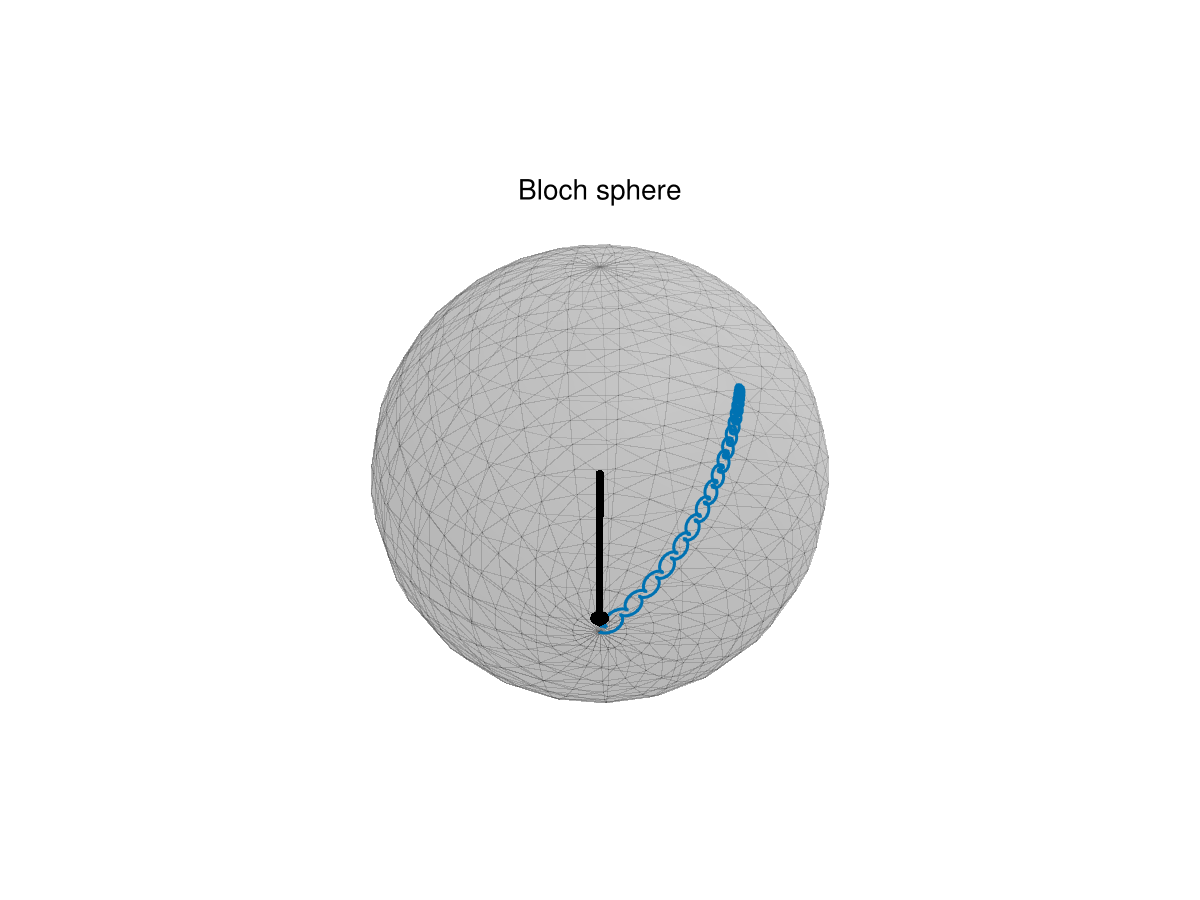

CairoMakie.Screen{IMAGE}


In [19]:
include("./Plotting.jl")
include("./Utils.jl")
using CairoMakie

psi_t[end]
println(typeof(psi_t))
println(psi_t[1],"\n---->\n", psi_t[end])
# println((statevectorToBlochvector.(psi_t)))
fig = Figure()
bloch = bloch_plot!(fig[1,1], tout, psi_t)
text!(bloch, 0, 0, 1.25, text="Bloch sphere", align=(0.5,0))
display(fig)

In [16]:
psi_t[end]

Ket(dim=2)
  basis: Spin(1/2)
 -0.05053769772379708 - 0.27375630203645673im
    0.960469095468272 + 0.00161034064167454im

In [17]:
psi_t

111-element Vector{Ket{SpinBasis{1//2, Int64}, Vector{ComplexF64}}}:
 Ket(dim=2)
  basis: Spin(1/2)
 0.0 + 0.0im
 1.0 + 0.0im
 Ket(dim=2)
  basis: Spin(1/2)
          -1.55e-14 - 2.834049599e-8im
 0.9999999999999997 + 0.0im
 Ket(dim=2)
  basis: Spin(1/2)
      -2.188221e-11 - 4.4667618505e-7im
 0.9999999999959271 + 5.7e-16im
 Ket(dim=2)
  basis: Spin(1/2)
      -4.041702e-11 - 2.25348773934e-6im
 0.9999999999965045 + 3.0e-16im
 Ket(dim=2)
  basis: Spin(1/2)
     -2.3556253e-10 - 7.05257438675e-6im
 0.9999999999796141 + 5.0e-17im
 Ket(dim=2)
  basis: Spin(1/2)
     -1.18724517e-9 - 1.701980327637e-5im
 0.9999999998540255 + 9.31e-15im
 Ket(dim=2)
  basis: Spin(1/2)
     -4.27911746e-9 - 3.486331437162e-5im
 0.9999999993214724 + 1.4938e-13im
 Ket(dim=2)
  basis: Spin(1/2)
    -1.192571422e-8 - 6.377836899547e-5im
 0.9999999979494583 + 3.1367e-13im
 Ket(dim=2)
  basis: Spin(1/2)
    -2.930183787e-8 - 0.00010734947127968im
 0.9999999943059662 + 1.06588e-12im
 Ket(dim=2)
  basis: Spin(1/2)
 

In [20]:
b = NLevelBasis(3)  # |0>, |1>, |r>
b2 = tensor(b, b)

[NLevel(N=3) ⊗ NLevel(N=3)]

In [21]:
b

NLevel(N=3)

In [23]:
basisstate(b,  1)

Ket(dim=3)
  basis: NLevel(N=3)
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [29]:
transition(b, 2, 3) * basisstate(b, 3)

Ket(dim=3)
  basis: NLevel(N=3)
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im

In [33]:
identityoperator(b) * basisstate(b, 2)

Ket(dim=3)
  basis: NLevel(N=3)
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im

In [35]:
tensor(identityoperator(b), transition(b, 2, 3)) 

Operator(dim=9x9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
      ⋅            ⋅            ⋅       …       ⋅            ⋅     
      ⋅            ⋅            ⋅               ⋅            ⋅     
      ⋅            ⋅            ⋅               ⋅            ⋅     
      ⋅            ⋅            ⋅               ⋅            ⋅     
      ⋅            ⋅            ⋅          1.0 + 0.0im       ⋅     
      ⋅            ⋅            ⋅       …       ⋅       1.0 + 0.0im
      ⋅            ⋅            ⋅               ⋅            ⋅     
      ⋅            ⋅            ⋅               ⋅            ⋅     
      ⋅            ⋅            ⋅               ⋅            ⋅     

In [36]:
using QuantumOptics
using LinearAlgebra

computational = SpinBasis(1//2)

I = identityoperator(computational)
σx = sigmax(computational)
σy = sigmay(computational)
σz = sigmaz(computational)
σ_vec = [σx, σy, σz];

down = spindown(computational)
up = spinup(computational)
;

In [37]:
function twoLevelSysFromParameters(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H)
    return tout, psi_t, t->H(t, nothing)
end

function rydberg_blockaded_system(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H_01(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 
    H_11(t, ignored) = sqrt(2)*Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_01)
    _,    psi11_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_11)
    return tout, (psi01_t, t->H_01(t, nothing)), (psi11_t, t->H_11(t, nothing))
end

rydberg_blockaded_system (generic function with 1 method)

In [ ]:
function implement(params)
    Ψ₀, Δ, Ω, ϕ, T = params

    H_01(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 
    H_11(t, ignored) = sqrt(2)*Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, 100)
    tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_01)
    _,    psi11_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_11)
    return tout, (psi01_t, t->H_01(t, nothing)), (psi11_t, t->H_11(t, nothing))
end

function fidelity(params)
    Ψ₀, Δ, Ω, ϕ, T = params

    tout, (psi_t, t->H_01(t, nothing)), (psi11_t, t->H_11(t, nothing)) = implement(params)

    zero_inner_01 = abs(psi_t[end][2])
    ϕ_01 = angle(psi_t[end][2])

    zero_inner_11 = abs(psi_t[end][2])
    ϕ_11 = angle(psi_t[end][2])
    F = abs((1+2*zero_inner_01+cis(ϕ_11 - 2*ϕ_01 - π)*zero_inner_11)/4)
    return F
end

9×9 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     1.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  1.0+0.0im

In [49]:
function implement(params)
    Ψ₀, Δ, Ω, ϕ, T = params

    H_01(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 
    H_11(t, ignored) = sqrt(2)*Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, 100)
    tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_01)
    _,    psi11_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_11)
    return tout, (psi01_t, t->H_01(t, nothing)), (psi11_t, t->H_11(t, nothing))
end

implement (generic function with 1 method)

In [84]:
using Interpolations
# Ω_points = 2π .* [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] #MHz I think
# Δ_points = 2π .* [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] #MHz I think

Ω_points = 2π .* [0.0, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0] #MHz I think
Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08] #MHz I think
ϕ_points = 2π .* [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ts = range(0, T, length(Ω_points))
Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t)
Ω(t) = cubic_spline_interpolation(ts, Ω_points)(t) 
ϕ(t) = cubic_spline_interpolation(ts, ϕ_points)(t)

H_01(t, ignored) = Ω(t)/2*(cos(ϕ(t))*σx + sin(ϕ(t))*σy) - Δ(t)*I/2 - Δ(t)*σz/2
H_11(t, ignored) = sqrt(2)*Ω(t)/2*(cos(ϕ(t))*σx + sin(ϕ(t))*σy) - Δ(t)*I/2 - Δ(t)*σz/2

tspan = range(0, T, 100)
tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, down, H_01)
_,    psi11_t = timeevolution.schroedinger_dynamic(tspan, down, H_11)
;

In [188]:
initial = [0.001, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0001, 
    4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
min = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    -2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -2*pi]
max = [20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 
    25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0,
    2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi]
;

In [120]:
initial[1:10]

10-element Vector{Float64}:
 0.0
 0.412
 0.825
 1.237
 1.485
 1.485
 1.237
 0.825
 0.412
 0.0

In [195]:
function infidelity(funcs, T)
    Ω_points = funcs[1:10]
    Δ_points = funcs[11:20]
    ϕ_points = funcs[21:30]

    ts = range(0, T, length(Ω_points))
    Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t)
    Ω(t) = cubic_spline_interpolation(ts, Ω_points)(t) 
    ϕ(t) = cubic_spline_interpolation(ts, ϕ_points)(t)

    H_01(t, ignored) = Ω(t)/2*(cos(ϕ(t))*σx + sin(ϕ(t))*σy) - Δ(t)*I/2 - Δ(t)*σz/2
    H_11(t, ignored) = sqrt(2)*Ω(t)/2*(cos(ϕ(t))*σx + sin(ϕ(t))*σy) - Δ(t)*I/2 - Δ(t)*σz/2

    tspan = range(0, T, 100)
    tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, down, H_01)
    _,    psi11_t = timeevolution.schroedinger_dynamic(tspan, down, H_11)

    zero_inner_01 = abs(psi01_t[end][2])
    ϕ_01 = angle(psi_t[end][2])

    zero_inner_11 = abs(psi11_t[end][2])
    ϕ_11 = angle(psi11_t[end][2])
    F = abs((1+2*zero_inner_01+cis(ϕ_11 - 2*ϕ_01 - π)*zero_inner_11)/4)
    return 1-F, tout, Δ, Ω, ϕ
end

infidelity (generic function with 2 methods)

In [189]:
using Optim
result = optimize(funcs -> infidelity(funcs,T), min, max, initial, Fminbox(NelderMead()))

println(result)
println("Optimal params: ", Optim.minimizer(result))

 * Status: success

 * Candidate solution
    Final objective value:     4.049620e-08

 * Found with
    Algorithm:     Fminbox with Nelder-Mead

 * Convergence measures
    |x - x'|               = 0.00e+00 ≤ 0.0e+00
    |x - x'|/|x'|          = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 5.01e-06 ≰ 1.0e-08

 * Work counters
    Seconds run:   48  (vs limit Inf)
    Iterations:    4
    f(x) calls:    4189
    ∇f(x) calls:   4
    ∇f(x)ᵀv calls: 0

Optimal params: [0.031617408280089666, 2.283967452301964, 3.2966307130129158, 1.0557202639438505, 1.2317796246086279, 0.7962868626468587, 0.1763238311663596, 2.746324468916378, 2.328734652147022, 0.0389373700534951, 0.680223234242508, 5.5770290866962595, 6.963501922338506, 1.1504124156840805, 0.03407607494155035, 0.1613565825271162, 0.8191061290474371, 6.563346899081755, 5.734468380180247, 1.0867223864382358, -0.10556282549927877, -0.10680154

In [197]:
inF, tout, Δ, Ω, ϕ = infidelity([0.031617408280089666, 2.283967452301964, 3.2966307130129158, 1.0557202639438505, 1.2317796246086279, 0.7962868626468587, 0.1763238311663596, 2.746324468916378, 2.328734652147022, 0.0389373700534951, 0.680223234242508, 5.5770290866962595, 6.963501922338506, 1.1504124156840805, 0.03407607494155035, 0.1613565825271162, 0.8191061290474371, 6.563346899081755, 5.734468380180247, 1.0867223864382358, -0.10556282549927877, -0.10680154171271694, 0.07757404818763218, 0.0869875395388939, -0.03589036470562689, -0.05907098253103157, -0.14051910805594564, -0.051987274077370575, 0.006683478508750277, -0.06158316772455575], T)



ErrorException: invalid assignment to constant Main.Δ. This redefinition may be permitted using the `const` keyword.

In [190]:
T

2.6

In [ ]:
# plotting
fig = Figure()
ax1 = Axis(fig[1, 1], yticklabelcolor = :blue,

    title = "Pulse shapes",
    xlabel = "Time",
    ylabel = L"Pulse amplitude",
    xticks = (0:0.5:tmax)
)
ax2 = Axis(fig[1, 1], yticklabelcolor = :red, yaxisposition = :right,
    # yticks = sin.([-1, 0, 1]), ["-π", "-π/2", "0", "π/2", "π"]
    yticks = (sin.([-π/2, 0, π/2]), [L"
", "0", L"
",]),
    ylabel = L"
 of phase accumulated on 
",
)

hidespines!(ax2)
hidexdecorations!(ax2)

lines!(ax1, Ts, ending_population, color = :blue)
lines!(ax2, Ts, x -> sin.(ending_phase(x)), color = :red)
display(fig)
     

In [75]:
abs2(psi11_t[end][2])


0.9997237207429509

In [ ]:
angle(psi01_t[end][2])

1.7624914780540462

In [77]:
angle(psi11_t[end][2])

-1.6138265937908887

In [86]:
1/2 - cos(angle(psi11_t[end][2]) - 2*angle(psi01_t[end][2]))/2

0.40949875099161304

In [83]:
T=2.6

2.6